In [1]:
import numpy as np, pandas as pd, geopandas as gpd
from tools.core import *
from tools.clustering import *

from scipy.stats import pearsonr, kendalltau
from scipy.spatial.distance import pdist, squareform

import matplotlib as mpl
import matplotlib.pyplot as plt, seaborn as sns

In [2]:
sns.set_palette('colorblind')
sns.set_context("paper", rc={"font.size": 6, "axes.titlesize": 7, "axes.labelsize": 7, "xtick.labelsize":6, "ytick.labelsize":6, 'legend.fontsize':6, "legend.title_fontsize":7})
plt.rcParams['svg.fonttype'] = 'none'
cm = 1/2.54  # centimeters in inches

In [3]:
df_vectors = pd.read_csv('outputs/ew_occupations/df_vectors.csv', index_col=0)
df_occs = pd.read_csv('outputs/ew_occupations/df_occs.csv', index_col=0)
df_occs.index = df_occs.index.astype(str)
df_trad = pd.read_csv('outputs/ew_occupations/df_trad.csv', index_col=0,)

gdf = gpd.read_file("data/ew_occupations/la_shapefile.zip")
gdf = gdf.set_index('LAD24CD').loc[df_vectors.index][['LAD24NM', 'geometry']]
gdf['n_population'] = df_trad.sum(axis=1)
gdf['population'] = gdf['n_population'] / gdf['n_population'].sum()

# Similarity matrices

In [4]:
dict_Z = {'I': np.eye(41)}

## Skills

Occupations are similar if the same skills are important for them.

The crosswalk from SOC2020 codes to ONET codes is from NFER (https://www.nfer.ac.uk/key-topics-expertise/education-to-employment/the-skills-imperative-2035/resources/systematic-mapping-of-soc-2020/)

The mapping of ONET occupation codes to skills is from ONET (https://www.onetcenter.org/dictionary/30.2/excel/skills.html). The mapping assigns an 'importance' between 1 and 5 to each of 35 skills for each occupation.

In [5]:
df_skills_raw = pd.read_csv("data/ew_occupations/onet_skills.csv")

df_skills_im = df_skills_raw[df_skills_raw['Scale ID'] == 'IM'].reset_index(drop=True)
srs_skillvectors = df_skills_im.groupby('O*NET-SOC Code')[['Element Name', 'Data Value']].apply(lambda x: x.sort_values('Element Name')['Data Value'].tolist())

df_crosswalk = pd.read_csv('data/ew_occupations/soc_onet_crosswalk.csv')
df_crosswalk['3dig'] = df_crosswalk['SOC2020'].apply(lambda x: str(x)[:3])

Each 3 digit SOC code maps to multiple ONET occupation codes, few of which are absent from the skills data. Here we check that most of them are present.

In [6]:
df_occs_skills = df_occs.copy()
df_occs_skills['onet_occs'] = df_crosswalk.groupby('3dig')['ONET'].unique().loc[df_occs_skills.index]
df_occs_skills['n_onet_total'] = df_occs_skills['onet_occs'].apply(len)

df_occs_skills['onet_occs_present'] = df_occs_skills['onet_occs'].apply(lambda x: [i for i in x if i in srs_skillvectors.index])
df_occs_skills['n_onet_present'] = df_occs_skills['onet_occs_present'].apply(len)

df_occs_skills['onet_occs_absent'] = df_occs_skills['onet_occs'].apply(lambda x: [i for i in x if not i in srs_skillvectors.index])

In [7]:
df_occs_skills[['label', 'n_onet_total', 'n_onet_present']]

,label,n_onet_total,n_onet_present
code,,,
111,Chief Executives and Senior Officials,2,2
113,Functional Managers and Directors,15,15
114,"Directors in Logistics, Warehousing and Transport",2,2
116,Senior Officers in Protective Services,7,7
121,Managers and Proprietors in Agriculture Relate...,2,2
211,Natural and Social Science Professionals,36,32
214,Web and Multimedia Design Professionals,6,5
215,Conservation and Environment Professionals,10,10
216,Research and Development (R&D) and Other Resea...,2,2


Each 3 digit SOC code is embedded at the coordinates given by the mean importance vector of their ONET codes. We construct a similarity matrix with median similarity 0.1 by transforming the Euclidean distance with $d \mapsto \exp (-\tau d)$.

In [8]:
emb = np.array( df_occs_skills['onet_occs_present'].apply(lambda x: np.array(srs_skillvectors.loc[x].tolist()).mean(axis=0).tolist()).tolist() )
D = squareform( pdist(emb, metric='euclidean') )

tau = -np.log(0.1)/np.median(D[np.triu_indices_from(D, 1)])
Z = distance_to_similarity(D, tau=tau)

dict_Z['S'] = Z

In [9]:
np.savetxt('outputs/ew_occupations/Z_S.txt', dict_Z['S'], delimiter=',')

## Co-location

Occupations are similar if the same LAs specialise in them.

We embed each occupation into Euclidean space at the coordinates given by the RCA of each of the top 100 most populous LAs in it. We construct a similarity matrix with median similarity 0.1 using $d \mapsto \exp (-\tau d)$.

In [9]:
top100_idx = gdf.sort_values('population', ascending=False).head(100).index.tolist()
emb = np.log10( df_vectors.loc[top100_idx] / df_occs['population'] ).to_numpy().T
D = squareform( pdist(emb, metric='euclidean') )

tau = -np.log(0.1)/np.median(D[np.triu_indices_from(D, 1)])
Z = distance_to_similarity(D, tau=tau)

dict_Z['L'] = Z

In [11]:
np.savetxt('outputs/ew_occupations/Z_L.txt', dict_Z['L'], delimiter=',')

## Classification Hierarchy

Occupations are similar if they have the same 2 or 1-digit SOC code. Similarity=0.5 for 2-digit codes and 0.1 for 1-digit code.

In [10]:
Z = np.eye(41)

for i, icode in enumerate(df_occs.index):
    for j, jcode in enumerate(df_occs.index):
        if i == j:
            continue
        if icode[:2] == jcode[:2]:
            Z[i, j] = 0.5
            continue
        if icode[0] == jcode[0]:
            Z[i, j] = 0.1
            continue

dict_Z['H'] = Z

In [13]:
np.savetxt('outputs/ew_occupations/Z_H.txt', dict_Z['H'], delimiter=',')

# Analysis

If you did not construct the similarity matrices, run this code

In [11]:
dict_Z = {'I': np.eye(41)}
for zname in ['S', 'L', 'H']:
    dict_Z[zname] = np.loadtxt(f'outputs/ew_occupations/Z_{zname}.txt', delimiter=',')

### Plotting utils

In [12]:
def classical_MDS(D, n_components=2, tol=1e-12):
    """
    Classical MDS (Torgerson) from distance matrix D.
    - D: (n,n) numpy array of pairwise distances (finite)
    - n_components: target dimension
    Returns X: (n, n_components) embedding
    """
    n = D.shape[0]
    D2 = D ** 2

    J = np.eye(n) - np.ones((n, n)) / n
    B = -0.5 * J.dot(D2).dot(J)
    B = (B + B.T) / 2.0

    # eigendecomposition
    eigvals, eigvecs = np.linalg.eigh(B)
    idx = np.argsort(eigvals)[::-1]
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]
    # keep positive eigenvalues above tol
    positive = eigvals > tol
    if not np.any(positive):
        # all nonpositive: return zeros
        return np.zeros((n, n_components))
    L = np.sqrt(np.maximum(eigvals[positive], 0.0))
    V = eigvecs[:, positive]
    X_full = V * L[np.newaxis, :]   # each column scaled by sqrt(eig)
    if X_full.shape[1] >= n_components:
        X = X_full[:, :n_components]
    else:
        # pad with zeros if fewer positive eigenvalues
        pad = np.zeros((n, n_components - X_full.shape[1]))
        X = np.hstack([X_full, pad])
    return X

pos = classical_MDS(-np.log(dict_Z['S']) , 2)
df_occs['x_S'] = pos[:, 0]
df_occs['y_S'] = pos[:, 1]

pos = classical_MDS(-np.log(dict_Z['L']) , 2)
df_occs['x_L'] = pos[:, 0]
df_occs['y_L'] = pos[:, 1]
df_occs['x_L'] *= -1

In [13]:
dict_color = {
    k: sns.color_palette('colorblind')[{'I':0, 'S':1, 'L':2, 'H':4}[k]] for k in dict_Z
}

dict_3colorpalette = {
    k: [sns.light_palette(color=v, n_colors=3)[1], v, sns.dark_palette(color=v, n_colors=3)[1]] for k,v in dict_color.items()
}

dict_labels = {
    'I': 'none',
    'S': 'skills',
    'L': 'co-location',
    'H': 'hierarchy'
}

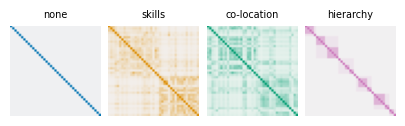

In [14]:
fig, axes = plt.subplots(1,4,figsize=(10*cm, 5*cm), layout='constrained')

for zname, ax in zip(dict_Z, axes):
    im = ax.imshow(dict_Z[zname], vmin=0, vmax=1, cmap=sns.light_palette(dict_color[zname], as_cmap=True))
    ax.set_axis_off()
    ax.set_title(dict_labels[zname])

## Entropy

In [15]:
for zname, Z in dict_Z.items():
    gdf[f'2_entropy_{zname}'] = df_vectors.apply(lambda x: get_rao(Z, x.to_numpy()), axis=1)

Correlations

In [16]:
for alpha in [2,3,4]:
    print(alpha)
    temp = pd.DataFrame(index=gdf.index)
    for zname, Z in dict_Z.items():
        temp[dict_labels[zname]] = get_entropy(Z, alpha, df_vectors.to_numpy())
    print( np.round(temp.corr(method='kendall'), 3) )

2
              none  skills  co-location  hierarchy
none         1.000   0.631        0.677      0.811
skills       0.631   1.000        0.536      0.640
co-location  0.677   0.536        1.000      0.782
hierarchy    0.811   0.640        0.782      1.000
3
              none  skills  co-location  hierarchy
none         1.000   0.585        0.642      0.807
skills       0.585   1.000        0.523      0.629
co-location  0.642   0.523        1.000      0.764
hierarchy    0.807   0.629        0.764      1.000
4
              none  skills  co-location  hierarchy
none         1.000   0.566        0.634      0.812
skills       0.566   1.000        0.510      0.627
co-location  0.634   0.510        1.000      0.754
hierarchy    0.812   0.627        0.754      1.000


## Divergence

In [17]:
for zname, Z in dict_Z.items():
    gdf[f'2_div_from_pop_{zname}'] = df_vectors.apply(lambda x: get_sqmahalanobis(Z, x.to_numpy(), df_occs['population'].to_numpy()), axis=1)

In [18]:
for alpha in [2,3,4]:
    print(alpha)
    temp = pd.DataFrame(index=gdf.index)
    for zname, Z in dict_Z.items():
        temp[dict_labels[zname]] = get_divergence(Z, alpha, df_vectors.to_numpy(), df_occs['population'].to_numpy())
    print( np.round(temp.corr(method='kendall'), 3) )

2
              none  skills  co-location  hierarchy
none         1.000   0.787        0.799      0.888
skills       0.787   1.000        0.899      0.871
co-location  0.799   0.899        1.000      0.882
hierarchy    0.888   0.871        0.882      1.000
3
              none  skills  co-location  hierarchy
none         1.000   0.759        0.727      0.848
skills       0.759   1.000        0.904      0.872
co-location  0.727   0.904        1.000      0.847
hierarchy    0.848   0.872        0.847      1.000
4
              none  skills  co-location  hierarchy
none         1.000   0.741        0.695      0.838
skills       0.741   1.000        0.883      0.847
co-location  0.695   0.883        1.000      0.816
hierarchy    0.838   0.847        0.816      1.000


## Clustering

In [19]:
dict_c = {
    zname : Clustering.from_vectors(
        vectors=df_vectors.to_numpy(),
        weights=gdf['population'].to_numpy()
    )
    for zname in dict_Z
}

dict_results = {
    zname : dict()
    for zname, Z in dict_Z.items()
}

for zname, zresults in dict_results.items():
    for k in range(2,7):
        zresults[k] = dict_c[zname].fit(k, dict_Z[zname], 2, n_trials=100, verbose=False, random_seed=42, rel_tol=1e-12, max_iter=500)

(-0.04038013611761106, 1.0)

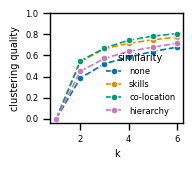

In [20]:
fig, ax = plt.subplots(1,1,figsize=(4.6*cm,4*cm), layout='constrained')

for zname in dict_Z:
    sns.lineplot(
        x = range(1,7),
        y = [0] + [i[2]/dict_c[zname].total_information for i in dict_results[zname].values()],
        ls='--', marker='o',
        color=dict_color[zname],
        label=dict_labels[zname]
    )
ax.set_ylabel('clustering quality')
ax.set_xlabel('k')
ax.legend(frameon=False, title='similarity')
ax.set_ylim(None, 1)

In [21]:
from sklearn.metrics import adjusted_mutual_info_score as AMI

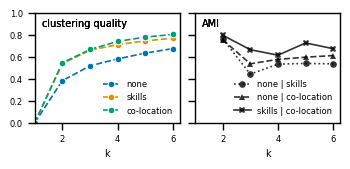

In [22]:
dict_pairs_plotstyle = {
    ('I', 'S') : dict(color='black', ls=':', marker='o'),
    ('I', 'L') : dict(color='black', ls='--', marker='^'),
    ('S', 'L') : dict(color='black', ls='-', marker='X')
}


fig, axes = plt.subplots(1,2,figsize=(8.6*cm,4*cm), layout='constrained', sharex=True, sharey=True)

for zname in list('ISL'):
    sns.lineplot(
        x = range(1,7),
        y = [0] + [i[2]/dict_c[zname].total_information for i in dict_results[zname].values()],
        label = f"{dict_labels[zname]}",
        ax = axes[0],
        ls = '--', marker='o', color=dict_color[zname],
    )
    axes[0].text(0.05, 0.95, 'clustering quality', transform=axes[0].transAxes, va='top', ha='left', fontsize=7,)

for (z1,z2) in dict_pairs_plotstyle:
    sns.lineplot(
        x = range(2,7),
        y = [AMI(dict_results[z1][k][1], dict_results[z2][k][1]) for k in range(2,7)],
        label = f"{dict_labels[z1]} | {dict_labels[z2]}",
        ax = axes[1], alpha=.8, markeredgewidth=0.0,
        **dict_pairs_plotstyle[(z1,z2)]
    )
    axes[1].text(0.05, 0.95, 'AMI', transform=axes[1].transAxes, va='top', ha='left', fontsize=7,)

for ax in axes:
    ax.legend(frameon=False, loc='lower right')
    ax.set_xlabel('k')
    ax.set_ylim(0, 1)
    ax.set_xlim(1,None)

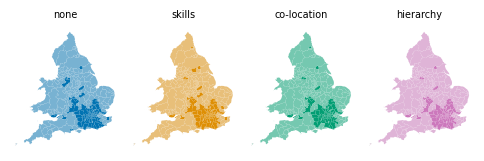

In [23]:
fig, axes = plt.subplots(1,4,figsize=(12*cm, 4*cm), layout='constrained')
for zname, ax in zip(dict_Z, axes):
    gdf.plot(color=[dict_3colorpalette[zname][i] for i in dict_results[zname][2][1]], ax=ax)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(dict_labels[zname])
    ax.set_axis_off()

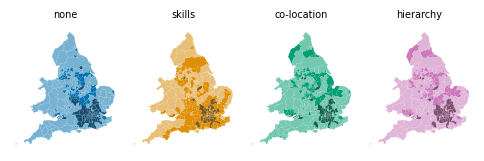

In [24]:
dict_manual_colormap = {k: {0:0, 1:1, 2:2} for k in dict_Z.keys()}
dict_manual_colormap['I']= {0:0, 1:2, 2:1}

fig, axes = plt.subplots(1,4,figsize=(12*cm, 4*cm), layout='constrained')
for zname, ax in zip(dict_Z, axes):
    gdf.plot(color=[dict_3colorpalette[zname][dict_manual_colormap[zname][i]] for i in dict_results[zname][3][1]], ax=ax)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(dict_labels[zname])
    ax.set_axis_off()

In [25]:
import itertools

(0.0, 1.0)

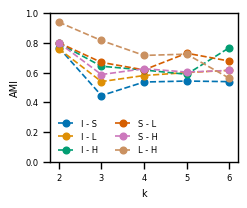

In [26]:
fig, ax = plt.subplots(1,1,figsize=(6*cm,5*cm), layout='constrained')
for z1, z2 in itertools.combinations(dict_Z.keys(), r=2):
    ax.plot(
        range(2,7),
        [AMI(dict_results[z1][k][1], dict_results[z2][k][1]) for k in range(2,7)],
        'o--',
        label = f"{z1} - {z2}"
    )
ax.set_ylabel('AMI')
ax.legend(frameon=False, ncols=2)
ax.set_xlabel('k')
ax.set_ylim(0, 1)

In [27]:
# AMI for k=3
for z1, z2 in itertools.combinations(dict_Z.keys(), r=2):
    print(dict_labels[z1], dict_labels[z2], np.round(AMI(dict_results[z1][3][1], dict_results[z2][3][1]), 2))

none skills 0.45
none co-location 0.54
none hierarchy 0.64
skills co-location 0.67
skills hierarchy 0.59
co-location hierarchy 0.82


In [28]:
df_occs.loc[['511', '925', '242', '813', '111']]

,label,population,x_S,y_S,x_L,y_L
code,,,,,,
511,Agricultural and Related Trades,0.044264,-0.895319,-0.136887,-1.072900,1.251611
925,Elementary Storage Occupations,0.081558,-0.613219,-0.341546,-1.072571,-1.246105
242,Finance Professionals,0.057323,1.444832,-0.911947,1.613147,-0.358729
813,Plant and Machine Operatives,0.013035,-1.846849,0.387967,-1.534948,-0.396184
111,Chief Executives and Senior Officials,0.019253,2.354918,1.207340,2.172711,0.678247


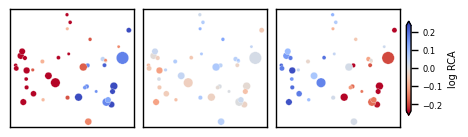

In [29]:
r = Result(df_vectors.to_numpy(), dict_c['S'].weights, dict_Z['S'], 2, dict_results['S'][3][0], dict_results['S'][3][1])

fig, axes = plt.subplots(1,3,figsize=((3.2*3+2)*cm, 3.2*cm), layout='constrained') 
halfrange = np.quantile(np.abs(np.log10(r.centers/ df_occs['population'].to_numpy())), .8)

for i, ax in enumerate(axes[::-1]):
    sns.scatterplot(
        df_occs,
        x= 'x_S', y='y_S',
        hue= np.log10(r.centers[i] / df_occs['population'].to_numpy()),
        hue_norm = mpl.colors.CenteredNorm(vcenter=0., halfrange=halfrange),
        palette = 'coolwarm_r',
        size='population', sizes=(5,80),
        legend=False,
        ax= ax,
    )
    ax.set_axis_on()
    ax.set_xlabel(''); ax.set_ylabel('')
    ax.set_xticks([]); ax.set_yticks([])

sm = mpl.cm.ScalarMappable(cmap=sns.color_palette('coolwarm_r',as_cmap=True), norm=mpl.colors.CenteredNorm(vcenter=0., halfrange=halfrange),)
sm.set_array([]) 
cbar = fig.colorbar(sm, ax=axes[-1], extend='both', shrink=0.8)
cbar.set_label("log RCA")

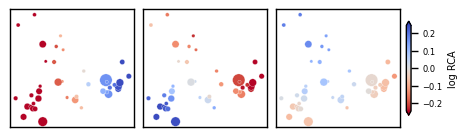

In [30]:
r = Result(df_vectors.to_numpy(), dict_c['L'].weights, dict_Z['L'], 2, dict_results['L'][3][0], dict_results['L'][3][1])

fig, axes = plt.subplots(1,3,figsize=((3.2*3+2)*cm, 3.2*cm), layout='constrained') 
halfrange = np.quantile(np.abs(np.log10(r.centers/ df_occs['population'].to_numpy())), .8)

for i, ax in enumerate(axes[::-1]):
    sns.scatterplot(
        df_occs,
        x= 'x_L', y='y_L',
        hue= np.log10(r.centers[i] / df_occs['population'].to_numpy()),
        hue_norm = mpl.colors.CenteredNorm(vcenter=0., halfrange=halfrange),
        palette = 'coolwarm_r',
        size='population', sizes=(5,80),
        legend=False,
        ax= ax,
    )
    ax.set_axis_on()
    ax.set_xlabel(''); ax.set_ylabel('')
    ax.set_xticks([]); ax.set_yticks([])
sm = mpl.cm.ScalarMappable(cmap=sns.color_palette('coolwarm_r',as_cmap=True), norm=mpl.colors.CenteredNorm(vcenter=0., halfrange=halfrange),)
sm.set_array([]) 
cbar = fig.colorbar(sm, ax=axes[-1], extend='both', shrink=0.8)
cbar.set_label("log RCA")


In [31]:
ri = Result(df_vectors.to_numpy(), dict_c['I'].weights, dict_Z['I'], 2, dict_results['I'][3][0], dict_results['I'][3][1])
ri.describe()

Results of clustering
-----------------
318 distributions of length 41 into 3 clusters.
Fraction of information explained: 0.521
-------------
Cluster 0:
154 points with 0.423 weight.
Within-cluster information=0.19, Between-cluster contribution=0.06
-------------
Cluster 1:
90 points with 0.336 weight.
Within-cluster information=0.177, Between-cluster contribution=0.254
-------------
Cluster 2:
74 points with 0.24 weight.
Within-cluster information=0.113, Between-cluster contribution=0.208


In [32]:
rs = Result(df_vectors.to_numpy(), dict_c['S'].weights, dict_Z['S'], 2, dict_results['S'][3][0], dict_results['S'][3][1])
rs.describe()

Results of clustering
-----------------
318 distributions of length 41 into 3 clusters.
Fraction of information explained: 0.663
-------------
Cluster 0:
130 points with 0.38 weight.
Within-cluster information=0.145, Between-cluster contribution=0.287
-------------
Cluster 1:
127 points with 0.374 weight.
Within-cluster information=0.103, Between-cluster contribution=0.008
-------------
Cluster 2:
61 points with 0.246 weight.
Within-cluster information=0.089, Between-cluster contribution=0.369


In [33]:
rl = Result(df_vectors.to_numpy(), dict_c['L'].weights, dict_Z['L'], 2, dict_results['L'][3][0], dict_results['L'][3][1])
rl.describe()

Results of clustering
-----------------
318 distributions of length 41 into 3 clusters.
Fraction of information explained: 0.67
-------------
Cluster 0:
154 points with 0.432 weight.
Within-cluster information=0.138, Between-cluster contribution=0.026
-------------
Cluster 1:
96 points with 0.292 weight.
Within-cluster information=0.089, Between-cluster contribution=0.265
-------------
Cluster 2:
68 points with 0.277 weight.
Within-cluster information=0.103, Between-cluster contribution=0.379
